In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
pathresults = "../scripts/results/"
data_file_delimiter = ","
import re

import seaborn as sns
viridis = matplotlib.colormaps.get_cmap('Set1')
import matplotlib.ticker as mtick
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

l_styles = {5:'-',38:'--',44:'-.',61:':'}
# Define the color dictionary
c_styles = {
    'baseline':'#377EB8',  # Blue
    'earlyDry':  '#4DAF4A' ,  # Green
    'lateDry': '#E41A1C'  # red
}
evalTime = 25.

path2file_ = r'/{}_{}/'


In [ ]:
def getVal(filename,dtype=float, header="infer",names = None):
    fullpath = pathresults + filename
    data_file_delimiter = ","
    return pd.read_csv(fullpath,delimiter=data_file_delimiter, 
                 header=None, 
                 index_col=False)

def getVal_(filename,dtype=float, header="infer",names = None):
    fullpath = pathresults +filename
    data_file_delimiter = ","
    if names is None:
        largest_column_count = 0
        with open(fullpath, 'r') as temp_f:
            lines = temp_f.readlines()
        last_line = lines[-1].strip()
        #print('last_line',last_line)
        array_from_last_line = np.array(last_line.split(','), dtype=dtype)
        largest_column_count = len(array_from_last_line)
        names = [i for i in range(0, largest_column_count)]
        cst = pd.read_csv(fullpath,delimiter=data_file_delimiter, 
                          header = header, names = names)
        #print('cst',cst.shape)
    else:
        cst = pd.read_csv(fullpath,delimiter=data_file_delimiter, header = header, names = names)
    return cst
    
def getData_(cid, path2file):
    if cid == 0:
        fileName =path2file+ "theta.csv"
    elif cid == coordX:
        fileName = pathsoilshape + "cellcentersX.txt"
    elif cid == coordY:
        fileName = pathsoilshape + "cellcentersY.txt"
    elif cid == coordZ:
        fileName = pathsoilshape + "cellcentersZ.txt"
    elif cid == cellindxid:
        fileName = path2file + "cellIds.txt"
    elif cid == gotR:
        fileName = path2file + "seg2cell_vals.csv"
        return getVal_(fileName, dtype = int)
    else:
        fileName = path2file+"Soil_solute_conc"+str(cid)+".csv"        
    return getVal(fileName, dtype = float)


nKonz = 8
gotR = 9
coordX = 10
coordY = 11
coordZ = 12
cellindxid = 13
timeid = 14
scenarioid=15
psetid = 16

#wat	cs	cl	coa	cod	cca	ccd	css2	co2

soilData = ['theta', 'cs','cl', 'coa', 'cod', 'cca', 'ccd', 'css', 'co2','gotR',
            'cellcentersX','cellcentersY','cellcentersZ','cellindx','time', 'scenario', 'pSet' ]


nToGet = len(soilData) # all except pset and scenario

scenarios = ["earlyDry", "baseline", "lateDry"]
setIds = [5,44,61]
exceptPset = []#[('baseline','19'),('baseline','47'),('baseline','83')]
#result_list_compExcept = [path2file.format(scenario, str(setId)) for scenario, setId in exceptPsets]
dataInput = [(scenario, str(setId)) for scenario in scenarios for setId in setIds if (scenario, str(setId)) not in exceptPset ]

numPset = len(dataInput)
allPSets = [ i for i in range(numPset) if i not in exceptPset]

def getData():
    
    GiniAll = [[] for i in range(numPset)]
    
    for idSet, dI in enumerate(dataInput):
        GiniAll_ = [[] for i in range(nToGet)]
        print(idSet,end =", ")

        path2file = path2file_.format(dI[0], dI[1])
        print(path2file)

        time = np.array(list(
            pd.read_csv(pathresults + path2file + "time.txt", 
                           names = ["time","Qlight"])["time"][1:])) # because we have twice the initial value
        

        for cid in range(timeid):
            GiniAll_[cid]= getData_(cid, path2file)
            
        GiniAll_[timeid]= time
        GiniAll_[scenarioid]= dI[0]
        GiniAll_[psetid]= dI[1]
            
        GiniAll[idSet] = GiniAll_
    return GiniAll #cid pSet rr



def getDatanew():
    
    GiniAll = pd.DataFrame(columns=soilData)
    
    for idSet, dI in enumerate(dataInput):
        GiniAll_ = [[] for i in range(timeid)]
        
        GiniAllpd = pd.DataFrame(columns=soilData)
        print(idSet,end =", ")

        path2file = path2file_.format(dI[0], dI[1])
        print(path2file)

        time = np.array(list(
            pd.read_csv(pathresults + path2file + "time.txt", 
                           names = ["time","Qlight"])["time"][1:])) # because we have twice the initial value
        

        for cid in range(timeid):
            GiniAll_[cid]= getData_(cid, path2file)
            
            
        pdattimes = pd.DataFrame(columns=soilData)
        for ll, tt in enumerate(time):
            pdattime = pd.DataFrame(columns=soilData)
            for cid in range(timeid):
                pdattime[soilData[cid]] = GiniAll_[cid].iloc[ll]
            for cid in range(timeid):
                pdattime[soilData[cid]] = GiniAll_[cid].iloc[ll]
            pdattime["time"]= tt
            pdattimes = pdattimes.append(pdattime)
        pdattimes[ 'scenario']= dI[0] #  'scenario', 'pSet'
        pdattimes['pSet']= dI[1]
            
        GiniAll = GiniAll.append(pdattimes)

    return GiniAll 
    
GiniAll = getData()

In [16]:

for gidx, GiniAll_ in enumerate(GiniAll):
    print( GiniAll_[scenarioid] ,int(GiniAll_[psetid] ) )
    time = GiniAll_[timeid]
    #ggs = []
    for cid in range(gotR):
        gg0 = GiniAll_[cid].copy()
        gg0.columns = [soilData[cid]+str(cc) for cc in gg0.columns]
        gg0['time']=time
        gg0 = pd.wide_to_long(gg0, stubnames=[soilData[cid]], i = 'time',j='cellindx').reset_index(drop=True)
        if cid == 0:
            merged_df = gg0
        else:
            merged_df = pd.merge(merged_df, gg0, on=['time', 'cellindx'], how='outer')
        
    merged_df['timeidx'] = [np.where(time==ttt)[0][0] for ttt in merged_df['time']]
    gotrr = GiniAll_[gotR].copy()
    gotrr_ = gotrr.iloc[merged_df['timeidx']].reset_index(drop=True)
    merged_df['gotR'] = gotrr_.eq(merged_df['cellindx'],axis=0).any(1)
    merged_df['pSet'] =  int(GiniAll_[psetid] )
    merged_df['scenario'] =  GiniAll_[scenarioid] 
    if gidx == 0:
        completedf = merged_df
    else:
        completedf  = pd.concat([completedf,merged_df ])
    
cellcentersZs=  pd.read_csv(pathresults + pathsoilshape + "cellcentersZ.txt",
                            delimiter=data_file_delimiter, 
                 header=None, 
                 index_col=False).T
cellcentersZs.columns = ["depth"]
cellcentersZs['cellindx']=  pd.read_csv(pathresults + pathsoilshape + "cellIds.txt",
                            delimiter=data_file_delimiter, 
                 header=None, 
                 index_col=False).T
cellcentersZs['coordX']=  pd.read_csv(pathresults + pathsoilshape + "cellcentersX.txt",
                            delimiter=data_file_delimiter, 
                 header=None, 
                 index_col=False).T
cellcentersZs['coordY']=  pd.read_csv(pathresults + pathsoilshape + "cellcentersY.txt",
                            delimiter=data_file_delimiter, 
                 header=None, 
                 index_col=False).T

completedf = pd.merge(completedf, cellcentersZs, on=['cellindx'], how='outer')

earlyDry 5
earlyDry 44
earlyDry 61
baseline 5
baseline 44
baseline 61
lateDry 5
lateDry 44
lateDry 61


In [17]:

completedf["simulation"] = completedf["pSet"].apply(str) +"_"+ completedf["scenario"]  
completedf["volscv"] = 1 #cm3
completedf["cc"] = completedf["ccd"] + completedf["cca"]
completedf["co"] = completedf["cod"] + completedf["coa"]

In [18]:
completedf.to_pickle('./soil3dData.pkl')

##################################################

In [6]:
completedf = pd.read_pickle("./soil3dData.pkl") 

In [4]:
xlimcc=[min(list(completedf.loc[(completedf['time']==max(completedf['time'])
                                 ) & (completedf['gotR']), 
                          ['cc','ccd','cca'] ].min())),
        max(list(completedf.loc[(completedf['time']==max(completedf['time'])
                                 ) & (completedf['gotR']), 
                          ['cc','ccd','cca'] ].max()))]
xlimco=[min(list(completedf.loc[(completedf['time']==max(completedf['time'])
                                 ) & (completedf['gotR']), 
                          ['co','cod','coa'] ].min())),
        max(list(completedf.loc[(completedf['time']==max(completedf['time'])
                                 ) & (completedf['gotR']), 
                          ['co','cod','coa'] ].max()))]

In [6]:
#reset manually the lowest value for visualisation
xlimco[0]=-1.e-6/2
xlimcc[0]=-1.e-5/2

In [36]:
import string 
def bin_(dataframe, independent_variable, dependent_variable):
    
    if dependent_variable in ['cs', 'cl']:
        vol = "theta" # enough because volume is 1cm3
    else:
        vol = "volscv"
    dataframe[dependent_variable+"_"]=dataframe[dependent_variable]*dataframe[vol]
    grouped = dataframe.groupby(dataframe[independent_variable])

    # Step 3: Compute the sum of dependent variable for each bin and the mean of the independent variable
    bin_meansZ = grouped[independent_variable].mean()
    bin_meansX = (grouped[dependent_variable+"_"]).sum()/(grouped[vol]).sum()
    bin_minX = (grouped[dependent_variable]).max()
    bin_maxX = (grouped[dependent_variable]).min()
    return bin_meansZ.dropna(), bin_minX.dropna(), bin_maxX.dropna(), bin_meansX.dropna()
def bin_and_plot(dataframe, independent_variable, dependent_variable,                 
                 nrows, ncols, indexsubplot,age = 25,idplotlegend1=1,
                 idplotlegend2=2,idplotlegend3 = 3,anchor1=(0.8,0.5), 
                  sizeplot=(15,15),pad_=1.08,
                 anchor2=(0.8, 0.2),offsetsubplotname=0,# sameXlimPercolumns=False,
                 mysets = None,unit=None, doLogX=False,xlim = None, ylim = None,title = None,unitChange=1,
                 doLogY=False, colVar = None, xlabels=None, axs=None,
                 dominmax = True, fig=None, loc_=None, rect_=[0, 0.0, 1, 1],fontsizes=20):
    
    if indexsubplot==1:
        fig, axs = plt.subplots(nrows, ncols, figsize=sizeplot)  # Adjust the figure size as needed
    ax = axs.flat[indexsubplot-1]

    
    l_styles = {5:'-',44:'--',61:':'}
    # Define the color dictionary
    c_styles = {
    'baseline':'#8da0cb',  # Blue
    'earlyDry':  '#66c2a5' ,  # Green
    'lateDry': '#fc8d62'  # red
    }#

    if colVar is not None:
        maxV = dataframe[colVar].max()
        minV = dataframe[colVar].min()
        
    # Loop to plot each line
    if mysets is None:
        mysets = dataframe["simulation"].unique()
        mysets.sort()
        
    # cannot do it this way because i set the mean over each depth.
    if xlim is not None:
        ax.set_xlim(xmin=xlim[0]*unitChange, xmax=xlim[1]*unitChange)
    if False:
        xlim1, xlim2 = ax.set_xlim(xmin = min(dataframe.loc[(dataframe['time']==max(dataframe['time'])
                                 ) & (dataframe['gotR']), dependent_variable ])*0.9,
                               xmax = max(dataframe.loc[(dataframe['time']==max(dataframe['time'])
                                 ) & (dataframe['gotR']), dependent_variable ])
                              )
    for i in mysets:
        df_ = dataframe[(dataframe['simulation']==i) & (dataframe['gotR']) ].copy()#& (dataframe['time'].astype(int)==age)
        if age > 0:
            df_ = df_[abs(df_['time'].astype(float)-age)==min(abs(df_['time'].astype(float)-age))].copy()
        else:
            df_ = df_[df_['time']==max(df_['time'])].copy()
            
        if len(df_) > 0:
            bin_meansZ, bin_minX, bin_maxX, bin_meansX = bin_(df_, independent_variable, dependent_variable)
            
            print(df_['scenario'].unique()[0],df_['pSet'].unique()[0],dependent_variable,
                  bin_meansX.mean(),bin_meansX.std())
            
            ax.plot( bin_meansX.values*unitChange, bin_meansZ,
                                                             linewidth=3,
                         #label=f'{i}',
                         c=c_styles[df_['scenario'].unique()[0]],
                         linestyle=l_styles[df_['pSet'].unique()[0]]
                        )
            if dominmax:
                ax.fill_betweenx(bin_meansZ,
                              bin_minX*unitChange, bin_maxX*unitChange ,
                             alpha=0.1,color=c_styles[df_['scenario'].unique()[0]])
                
    # Color legend
    color_legend_elements = [
        Line2D([0], [0], color=c_styles['baseline'], lw=5, label='baseline'),
        Line2D([0], [0], color=c_styles['earlyDry'], lw=5, label='earlyDry'),
        Line2D([0], [0], color=c_styles['lateDry'], lw=5, label='lateDry')
    ]

    # Line style legend
    linestyle_legend_elements = [
    Line2D([0], [0], color='black', linestyle=l_styles[5], lw=6, label="highCO2"),
    #Line2D([0], [0], color='black', linestyle=l_styles[38], lw=6, label=38),
    Line2D([0], [0], color='black', linestyle=l_styles[44], lw=6, label="highMB"),
    Line2D([0], [0], color='black', linestyle=l_styles[61], lw=6, label="lowMUptake")
    ]


    if unit is None:
        unit = 'mol/cm3'
    if (indexsubplot%ncols) ==1:
        ax.set_ylabel('depth (cm)', fontsize=fontsizes) #
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=str(fontsizes))
    #ax.tick_params(axis='x', which='major', labelrotation=30, labelsize=18)

    if xlabels is None:
        if dependent_variable == '$CO_2$':
            ax.set_xlabel('Produced ' + dependent_variable+' ('+unit+')', fontsize=fontsizes)
        else:
            ax.set_xlabel( dependent_variable+' ('+unit+')', fontsize=fontsizes)
    else:
        
        if dependent_variable == 'co2':
            ax.set_xlabel('Produced ' + xlabels[dependent_variable] +' ('+unit+')', fontsize=fontsizes)
        else:
            ax.set_xlabel( xlabels[dependent_variable] +' ('+unit+')', fontsize=fontsizes)

    if ylim is not None:
        ax.set_ylim(ylim[0],ylim[1])

    if False:
        # Set x-axis to scientific format
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))
        ax.xaxis.set_major_formatter(formatter)
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2e}'))


    # Get the corresponding letter label
    label = '('+string.ascii_lowercase[offsetsubplotname+indexsubplot-1]+')'
    ax.annotate(
            label,
            xy=(0, 1.12), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=str(fontsizes), verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
    
    #plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2e'))
    #plt.gca().set_xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2e'))
    if doLogY:
        ax.set_yscale('log')
    if doLogX:
        ax.set_xscale('log')
    # idplotlegend2
    if (idplotlegend3 is not None) :
        if (indexsubplot == idplotlegend3):
            if loc_ is None:
                # Legend for mean values and range
                shape_legend = ax.legend(handles=[
                    Line2D([0], [0], color='black', lw=3, label='Mean values'),
                    Line2D([0], [0], color='black', alpha=0.1, lw=10, label='Range (min-max)')
                ], fontsize=fontsizes, loc='lower right', framealpha=1)
                ax.add_artist(shape_legend)
            else:
                # Legend for mean values and range
                shape_legend = fig.legend(handles=[
                    Line2D([0], [0], color='black', lw=3, label='Mean values'),
                    Line2D([0], [0], color='black', alpha=0.1, lw=10, label='Range (min-max)')
                ], fontsize=fontsizes, loc='lower right', framealpha=1)
                fig.add_artist(shape_legend)
                
    if (idplotlegend1 is not None) :
        if (indexsubplot == idplotlegend1):
            if loc_ is None:
                color_legend = ax.legend(handles=color_legend_elements, 
                           fontsize=fontsizes, title='scenario', title_fontsize=str(fontsizes), framealpha=1,
                           loc='lower right', #bbox_to_anchor=(0.3, 0.5), 
                           ncol=1)
                ax.add_artist(color_legend)

            else:
                color_legend = fig.legend(handles=color_legend_elements, 
                           fontsize=fontsizes, title='scenario', title_fontsize=str(fontsizes), framealpha=1,
                           loc=loc_, bbox_to_anchor=anchor1, 
                           ncol=1)                
                fig.add_artist(color_legend)

                

                linestyle_legend = fig.legend(handles=linestyle_legend_elements, 
                           fontsize=fontsizes, title='parameter set', title_fontsize=str(fontsizes), framealpha=1,
                           loc='center right', #bbox_to_anchor=(0.6, 0.3), 
                           ncol=1)
                fig.add_artist(linestyle_legend)

    elif indexsubplot == nrows*ncols:
        fig.legend(handles=color_legend_elements, 
                   fontsize=fontsizes, title='scenario', title_fontsize='25', framealpha=1,
                   loc='center left',bbox_to_anchor=(0.5, 0), 
                   ncol=1)
    if (idplotlegend2 is not None) :
        if (indexsubplot == idplotlegend2) and (loc_ is None):
            linestyle_legend = ax.legend(handles=linestyle_legend_elements, 
                       fontsize=fontsizes, title='parameter set', title_fontsize=str(fontsizes), framealpha=1,
                       loc='lower right', #bbox_to_anchor=(0.6, 0.3), 
                       ncol=1)
            ax.add_artist(linestyle_legend)
    elif indexsubplot == nrows*ncols:
        if loc_ is None:
            fig.legend(handles=linestyle_legend_elements, 
                       fontsize=fontsizes, title='parameter set', title_fontsize=str(fontsizes), framealpha=1,
                       loc='center', bbox_to_anchor=(0.5, -0.07), 
                       ncol=3)
        else:
            plt.legend(handles=linestyle_legend_elements, 
                       fontsize=fontsizes, title='parameter set', title_fontsize=str(fontsizes), framealpha=1,
                       loc=loc_, bbox_to_anchor=anchor1,#(0.5, -0.07), 
                       ncol=3)
    #if indexsubplot%2==0:
    if (indexsubplot%ncols) !=1:
        ax.yaxis.set_tick_params(labelleft=False)
    ax.grid(True)

    # Extract current y-tick labels
    yticks = ax.get_yticks()
    ytick_labels = [f'{int(abs(t))}' for t in yticks]

    # Set the modified labels back, keeping the original order
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_title(title,{'fontsize': fontsizes})

    plt.tight_layout()#rect=rect_,pad=pad_) #  (left, bottom, right, top), default: (0, 0, 1, 1)
    return fig, axs


baseline 44 cs 2.482704049937247e-06 1.4461449302282472e-07
earlyDry 44 cs 2.477680472793809e-06 6.662134262796559e-08
lateDry 44 cs 2.338383196192364e-06 1.7575824296644466e-08
baseline 5 cs 3.477833695960126e-06 3.675216030430318e-07
earlyDry 5 cs 3.3308378733631984e-06 1.7004846902038337e-07
lateDry 5 cs 3.290363690345346e-06 1.038764108244507e-07
baseline 61 cs 6.924668124463796e-06 1.4483802571852288e-06
earlyDry 61 cs 7.021948577267579e-06 1.1955693496680478e-06
lateDry 61 cs 1.0352745056646627e-05 1.7787492193845592e-06
baseline 44 cl 0.0006952227239887846 1.9575401420742704e-06
earlyDry 44 cl 0.0006963173718273086 2.2539786142679717e-06
lateDry 44 cl 0.0007032616648665354 4.245773470053874e-06
baseline 5 cl 0.000592646565602879 1.4924401446660665e-06
earlyDry 5 cl 0.0005938855993148173 1.8913406140558226e-06
lateDry 5 cl 0.0006003891314612495 3.934547357510102e-06
baseline 61 cl 0.0006482458255104939 1.992185686644643e-06
earlyDry 61 cl 0.0006496590417597771 2.4632471364816177e

<Figure size 1600x1200 with 0 Axes>

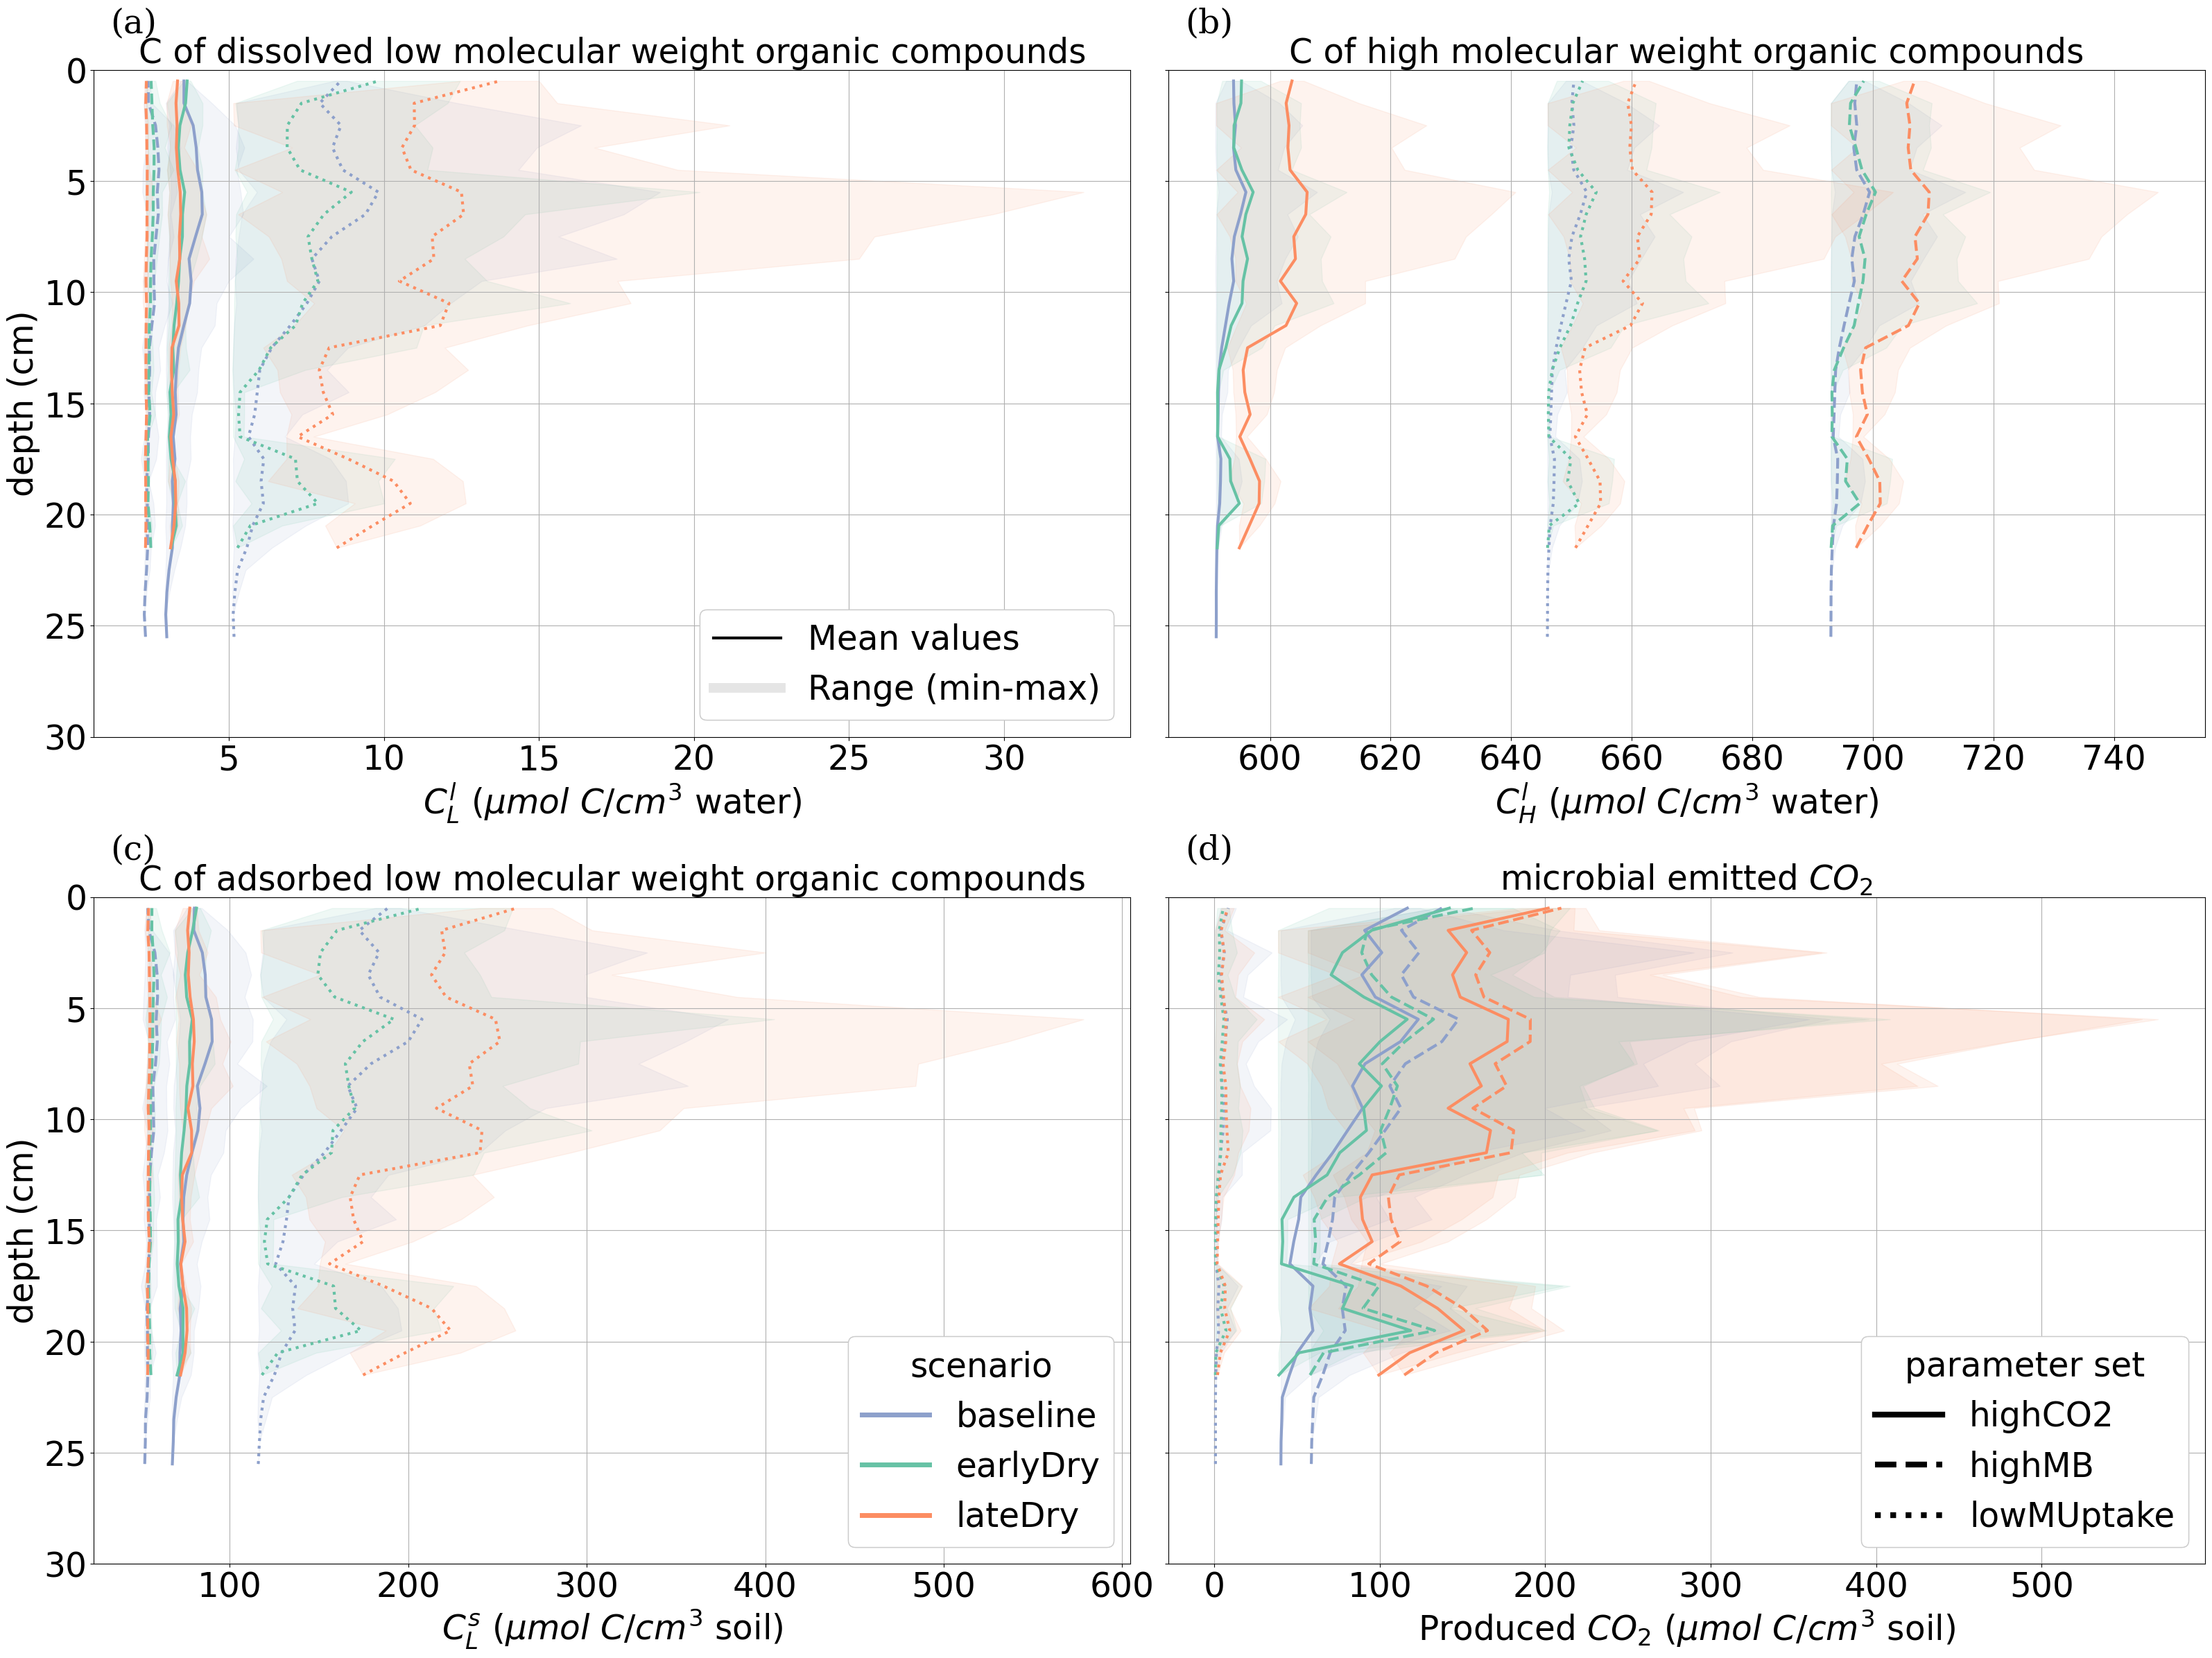

In [9]:
idsplot = [1,2,3,4,5,6,7,8,9,10]
units = ['$\mu mol~C/cm^3$ water','$\mu mol~C/cm^3$ water',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil']
xlabels = {'css': '$C_L^s$','co2': '$CO_2$',
           'coa': '$C_O^a$','cod': '$C_O^d$',
           'cca': '$C_C^a$','ccd': '$C_C^d$',
           'cs': '$C_L^l$','cl':'$C_H^l$','co2': '$CO_2$','cc': '$C_C$','co': '$C_O$' }  

titels = {'css': 'C of adsorbed low molecular weight organic compounds','co2': 'microbial emitted $CO_2$',
           'coa': 'active oligotrophs-C','cod': 'dormant oligotrophs-C',
           'cca': 'active copiotrophs-C','ccd': 'dormant copiotrophs-C',
           'cs': 'C of dissolved low molecular weight organic compounds','cl':'C of high molecular weight organic compounds',
          'cc': 'copiotrophs-C','co': 'oligotrophs-C' }  
xlims_ = [None, None,None, None,xlimcc,xlimco,xlimcc,xlimco,xlimcc,xlimco]
fig, axs = None, None
plt.figure(figsize=(16, 12)) #[completedf['pSet']!=5]
for nn, depvar in enumerate(['cs', 'cl','css','co2']): #,'cc','co','cca','coa','ccd','cod'
    age_ =-1# 25
    fig, axs = bin_and_plot(completedf, 'depth', depvar,#'cc',[completedf['pSet']!=5]
               2,2,#3,4, 
                            idsplot[nn],  doLogY=False,  offsetsubplotname =0,
                            sizeplot=(16*2, 12*2), idplotlegend1=3,idplotlegend2=4,idplotlegend3=1,
                 anchor1=(0.5,0.3), anchor2=(0.5, 0.6),unitChange = 1e6,
                 #doLogX=True, 
                 #colVar= colvars, 
                 age = age_,
                 unit = units[nn],
                xlabels=xlabels,title = titels[depvar],
                ylim = [-26,0], fig=fig, axs=axs, xlim=xlims_[nn], fontsizes=35
                )
    
plt.savefig('3ds_distribA.png')
plt.show()

baseline 44 cc 1.9990504126725594e-05 3.318006668405795e-06
earlyDry 44 cc 2.018762609487272e-05 3.087606598479072e-06
lateDry 44 cc 2.66968546462148e-05 3.822937279052324e-06
baseline 5 cc 9.90369915859489e-06 2.7979435323621034e-07
earlyDry 5 cc 9.993010639258667e-06 3.0005811071625755e-07
lateDry 5 cc 1.0592574565010517e-05 3.6622506215760996e-07
baseline 61 cc 1.1523360333175452e-05 1.722316610742477e-06
earlyDry 61 cc 1.1552651532797723e-05 1.3925704435122847e-06
lateDry 61 cc 1.2995692584304885e-05 1.6622665750297158e-06
baseline 44 co 9.51140538371315e-06 2.0708137847987973e-08
earlyDry 44 co 9.456627818910817e-06 8.712772648927095e-09
lateDry 44 co 9.484260868645378e-06 1.159863415744081e-08
baseline 5 co 9.312532389079374e-06 9.284050736108495e-09
earlyDry 5 co 9.300640272423392e-06 4.607287764708917e-09
lateDry 5 co 9.313475135545975e-06 6.340129359384759e-09
baseline 61 co 9.392825599245779e-06 3.959011016862852e-08
earlyDry 61 co 9.365594788089108e-06 2.190806833927683e-08


<Figure size 1600x2400 with 0 Axes>

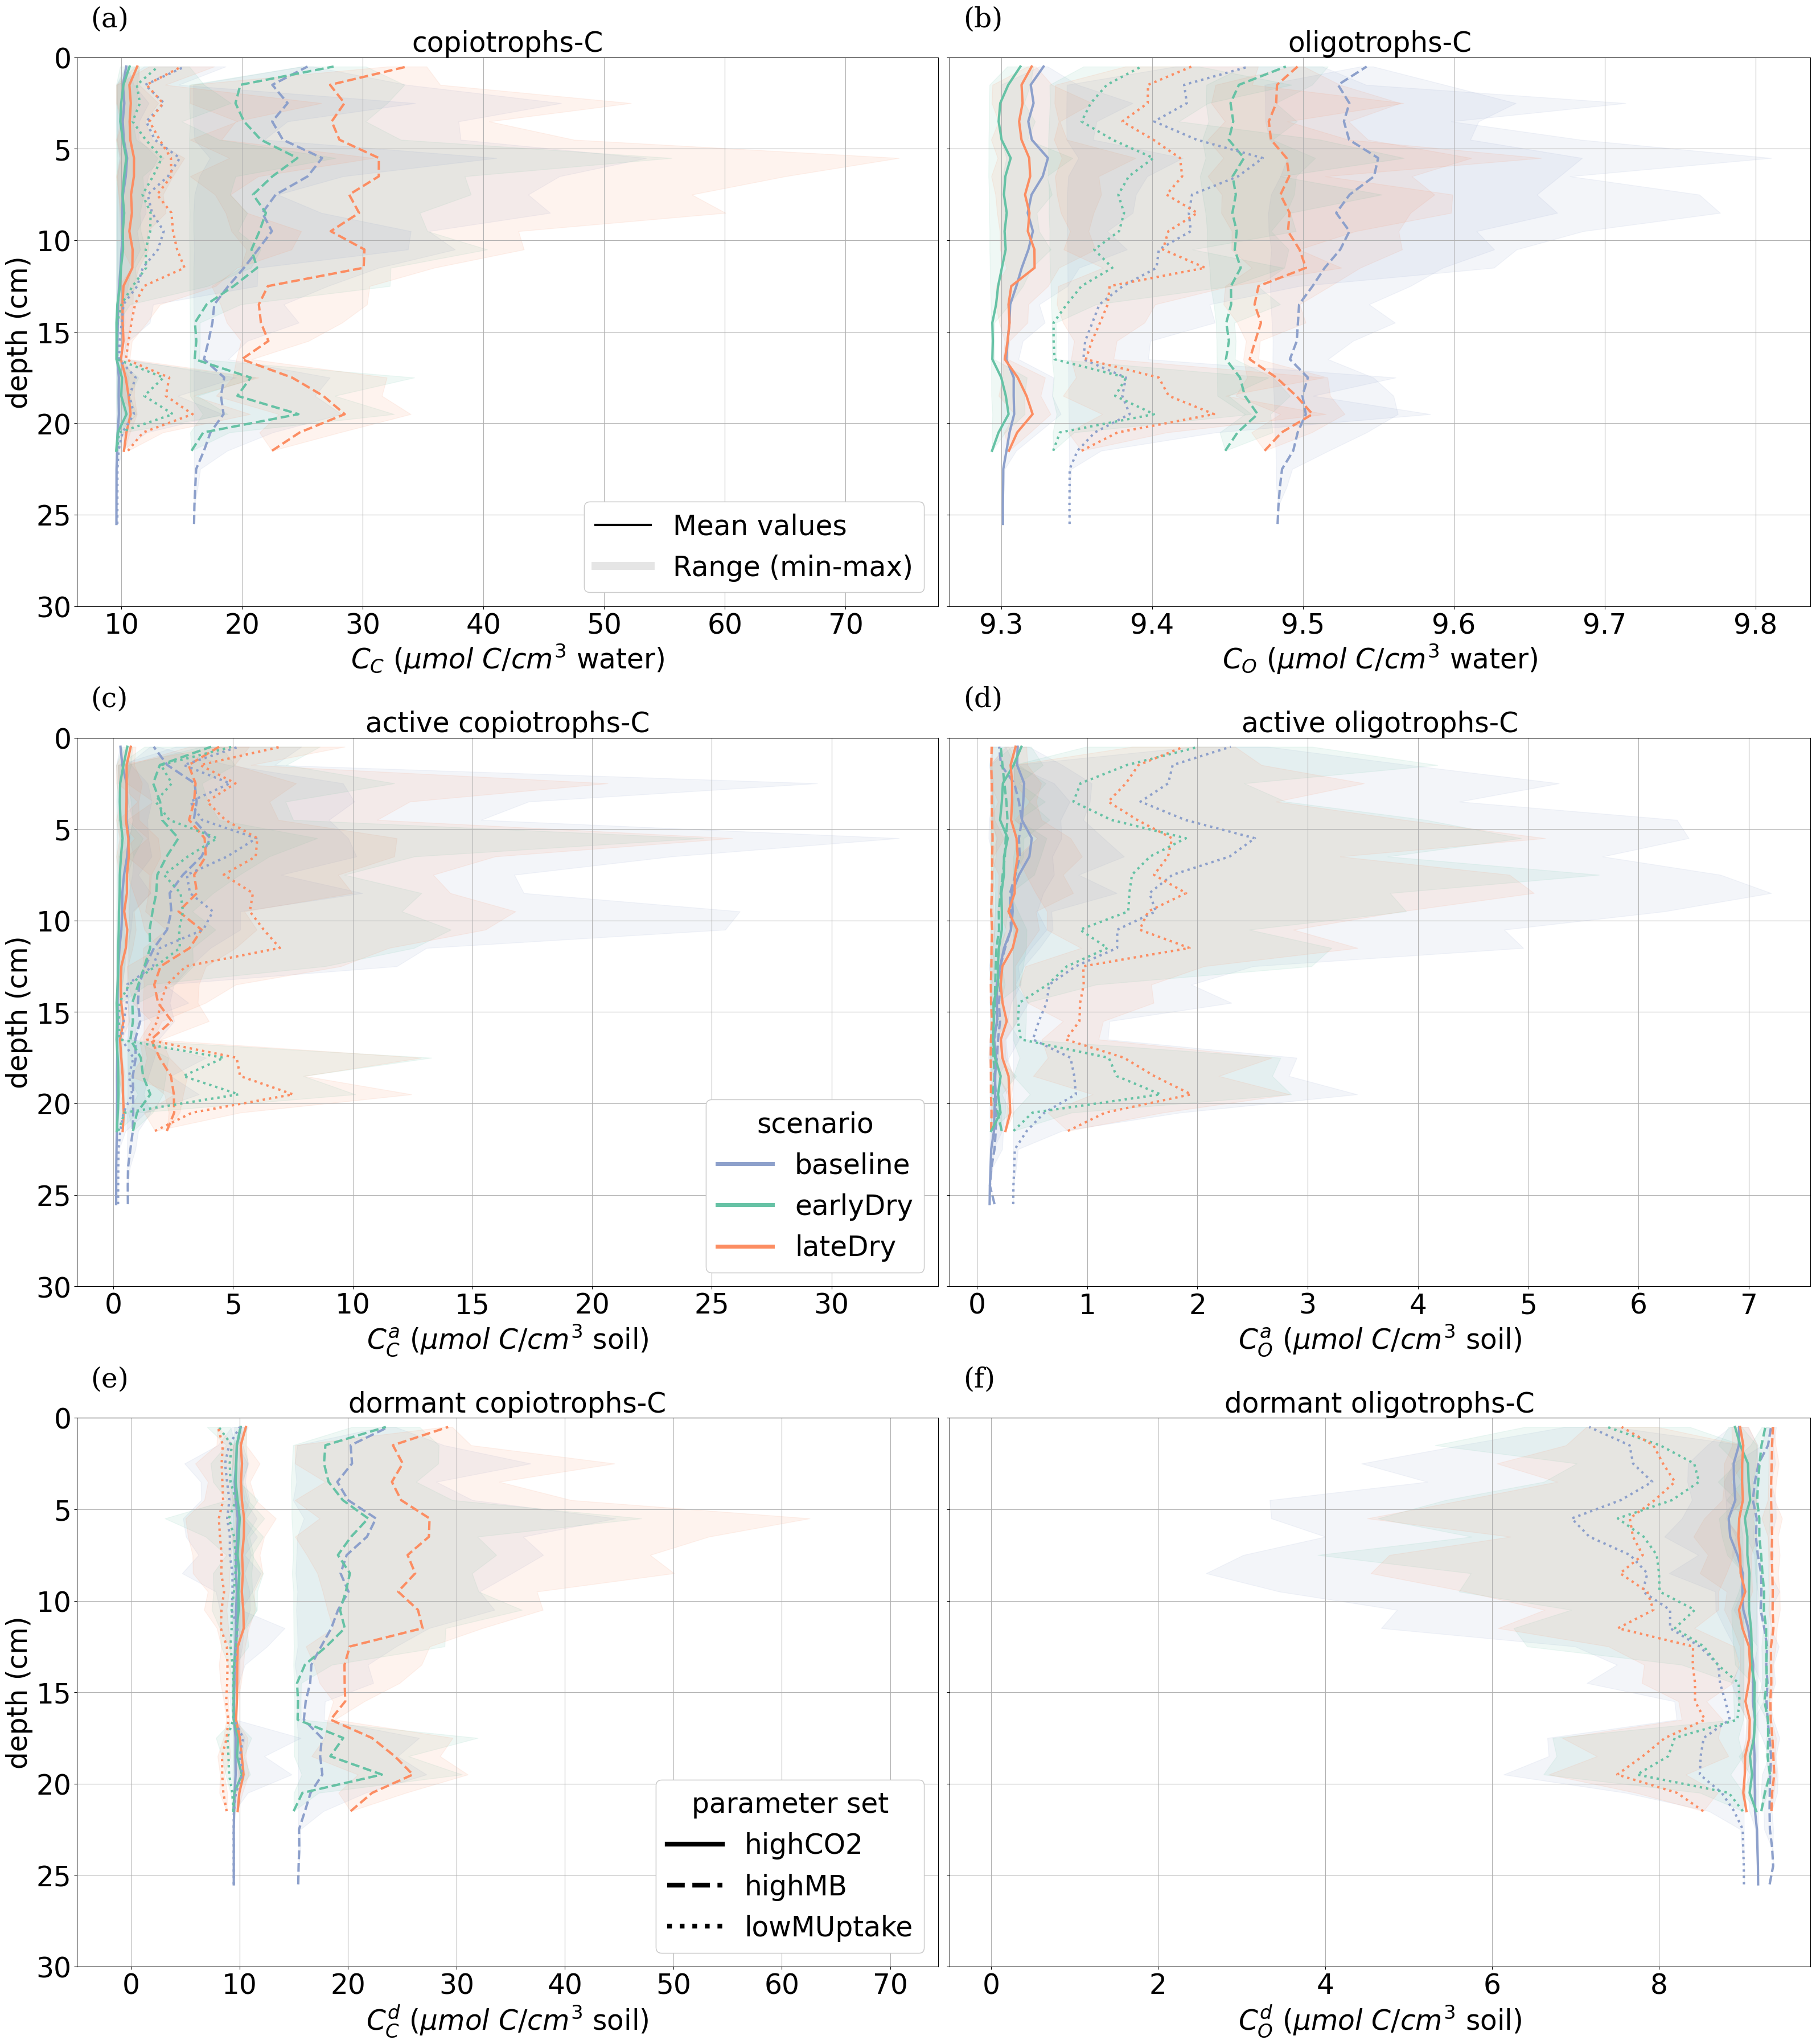

In [10]:
idsplot = [1,2,3,4,5,6,7,8,9,10]
units = ['$\mu mol~C/cm^3$ water','$\mu mol~C/cm^3$ water',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil',
         '$\mu mol~C/cm^3$ soil','$\mu mol~C/cm^3$ soil']
xlabels = {'css': '$C_L^s$','co2': '$CO_2$',
           'coa': '$C_O^a$','cod': '$C_O^d$',
           'cca': '$C_C^a$','ccd': '$C_C^d$',
           'cs': '$C_L^l$','cl':'$C_H^l$','co2': '$CO_2$','cc': '$C_C$','co': '$C_O$' }  

titels = {'css': 'C of adsorbed low molecular weight organic compounds','co2': 'microbial emitted $CO_2$',
           'coa': 'active oligotrophs-C','cod': 'dormant oligotrophs-C',
           'cca': 'active copiotrophs-C','ccd': 'dormant copiotrophs-C',
           'cs': 'C of dissolved low molecular weight organic compounds','cl':'C of high molecular weight organic compounds',
          'cc': 'copiotrophs-C','co': 'oligotrophs-C' }  
xlims_ = [None, None,None, None,xlimcc,xlimco,xlimcc,xlimco,xlimcc,xlimco]
fig, axs = None, None
plt.figure(figsize=(16, 12*2)) #[completedf['pSet']!=5]
for nn, depvar in enumerate(['cc','co','cca','coa','ccd','cod']):
    age_ =-1# 25
    fig, axs = bin_and_plot(completedf, 'depth', depvar,#'cc',[completedf['pSet']!=5]
               3,2,#3,4, 
                            idsplot[nn],  doLogY=False,  offsetsubplotname =0,
                            sizeplot=(16*2, 12*3), idplotlegend1=3,idplotlegend2=5,idplotlegend3=1,
                 anchor1=(0.5,0.3), anchor2=(0.5, 0.6),unitChange = 1e6,
                 #doLogX=True, 
                 #colVar= colvars, 
                 age = age_,
                 unit = units[nn],
                xlabels=xlabels,title = titels[depvar],
                ylim = [-26,0], fig=fig, axs=axs, xlim=xlims_[nn], fontsizes=35
                )
    
plt.savefig('3ds_distribB.png')
plt.show()